In [1]:
# Data Cleaning & Visualization Project
# Online Retail Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset

file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 541909
Number of columns: 8


In [3]:
# Display the first 5 rows

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nMissing value percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing value percentage:
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


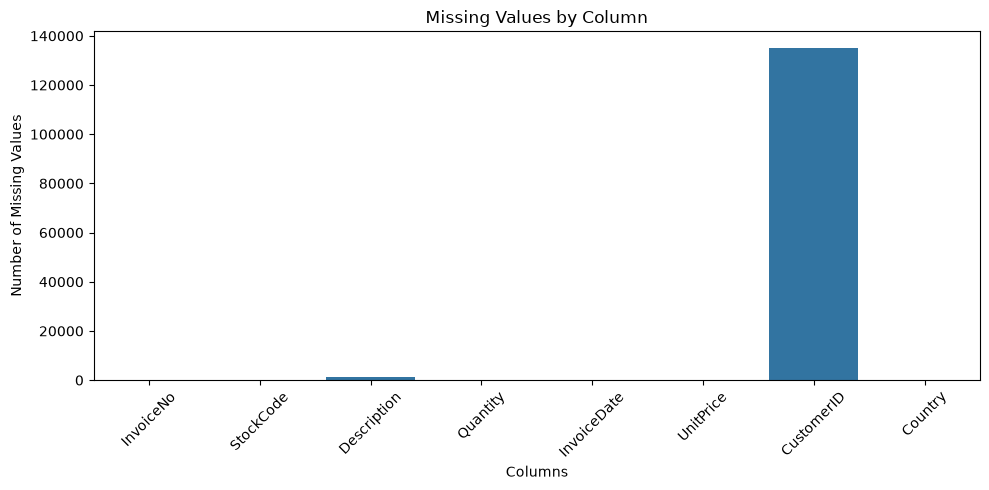

In [7]:
# Visualize missing values

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visualizations/missing_values.png")
plt.show()

In [8]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [9]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (536641, 8)


In [10]:
# Check for invalid Quantity and UnitPrice values

print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

Quantity <= 0: 10587
UnitPrice <= 0: 2512


In [11]:
# Display suspicious records

df[(df["Quantity"] <= 0) | (df["UnitPrice"] <= 0)].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom


In [5]:
# Statistical summary

df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [12]:
# Identify cancelled transactions

cancelled_transactions = df["InvoiceNo"].astype(str).str.startswith("C")

print("Cancelled transactions:", cancelled_transactions.sum())
print("Normal transactions:", (~cancelled_transactions).sum())

Cancelled transactions: 9251
Normal transactions: 527390


In [13]:
# Remove cancelled transactions

df = df[~cancelled_transactions].copy()

print("Shape after removing cancelled transactions:", df.shape)

Shape after removing cancelled transactions: (527390, 8)


In [14]:
# Check invalid prices after removing cancellations

print("Invalid UnitPrice values:", (df["UnitPrice"] <= 0).sum())

Invalid UnitPrice values: 2512


In [15]:
# Remove transactions with invalid UnitPrice

df = df[df["UnitPrice"] > 0].copy()

print("Shape after removing invalid prices:", df.shape)

Shape after removing invalid prices: (524878, 8)


In [16]:
# Handle missing product descriptions

df["Description"] = df["Description"].fillna("Unknown")

print("Missing Description values:", df["Description"].isnull().sum())

Missing Description values: 0


In [17]:
# Check missing CustomerID values

print("Missing CustomerID values:", df["CustomerID"].isnull().sum())
print("Available CustomerID values:", df["CustomerID"].notnull().sum())

Missing CustomerID values: 132186
Available CustomerID values: 392692


In [18]:
# Calculate total sales for each transaction

df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "TotalSales"]].head()

,Quantity,UnitPrice,TotalSales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [19]:
# Final data quality check

print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Final dataset shape: (524878, 9)

Missing values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
TotalSales          0
dtype: int64

Duplicate rows:
0


In [20]:
# Display cleaned dataset

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


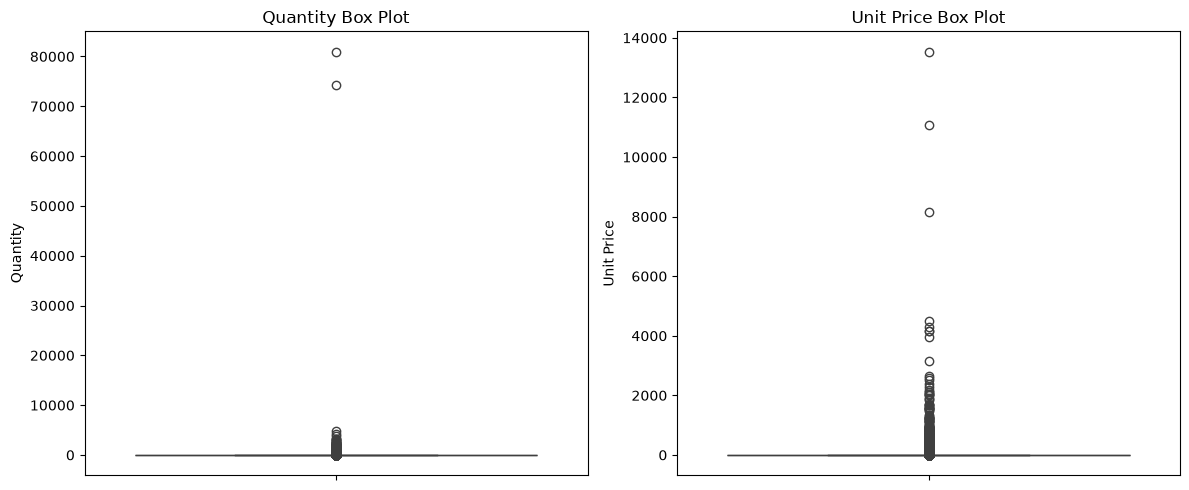

In [21]:
# Visualize Quantity and UnitPrice for outlier detection

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["Quantity"])
plt.title("Quantity Box Plot")
plt.ylabel("Quantity")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["UnitPrice"])
plt.title("Unit Price Box Plot")
plt.ylabel("Unit Price")

plt.tight_layout()
plt.savefig("../visualizations/outlier_boxplots.png")
plt.show()

In [22]:
# Function to detect outliers using IQR

def find_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)


quantity_result = find_outliers("Quantity")
price_result = find_outliers("UnitPrice")

print("Quantity:")
print("Q1:", quantity_result[0])
print("Q3:", quantity_result[1])
print("IQR:", quantity_result[2])
print("Lower Bound:", quantity_result[3])
print("Upper Bound:", quantity_result[4])
print("Number of Outliers:", quantity_result[5])

print("\nUnitPrice:")
print("Q1:", price_result[0])
print("Q3:", price_result[1])
print("IQR:", price_result[2])
print("Lower Bound:", price_result[3])
print("Upper Bound:", price_result[4])
print("Number of Outliers:", price_result[5])

Quantity:
Q1: 1.0
Q3: 11.0
IQR: 10.0
Lower Bound: -14.0
Upper Bound: 26.0
Number of Outliers: 27111

UnitPrice:
Q1: 1.25
Q3: 4.13
IQR: 2.88
Lower Bound: -3.0700000000000003
Upper Bound: 8.45
Number of Outliers: 37827


In [23]:
# Handle outliers using IQR capping

def cap_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values at the calculated boundaries
    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    return lower_bound, upper_bound


quantity_lower, quantity_upper = cap_outliers("Quantity")
price_lower, price_upper = cap_outliers("UnitPrice")

print("Quantity capped between:", quantity_lower, "and", quantity_upper)
print("UnitPrice capped between:", price_lower, "and", price_upper)

Quantity capped between: -14.0 and 26.0
UnitPrice capped between: -3.0700000000000003 and 8.45


In [24]:
# Recalculate TotalSales after outlier treatment

df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

print(df[["Quantity", "UnitPrice", "TotalSales"]].head())

   Quantity  UnitPrice  TotalSales
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


In [25]:
# Verify the maximum values after outlier treatment

print("Maximum Quantity:", df["Quantity"].max())
print("Maximum UnitPrice:", df["UnitPrice"].max())

Maximum Quantity: 26
Maximum UnitPrice: 8.45


## Exploratory Data Analysis

In [26]:
# Basic sales summary

total_revenue = df["TotalSales"].sum()
total_quantity = df["Quantity"].sum()
total_transactions = df["InvoiceNo"].nunique()
total_products = df["StockCode"].nunique()
total_countries = df["Country"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Quantity Sold:", total_quantity)
print("Total Transactions:", total_transactions)
print("Unique Products:", total_products)
print("Countries:", total_countries)

Total Revenue: 7181908.88
Total Quantity Sold: 3633303
Total Transactions: 19960
Unique Products: 3922
Countries: 38


In [27]:
# Top 10 countries by total revenue

country_sales = (
    df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_sales)

Country
United Kingdom    6173920.874
Germany            187851.330
EIRE               179759.960
France             162395.640
Netherlands         90528.750
Australia           47639.360
Switzerland         45047.560
Spain               42484.810
Belgium             36111.110
Norway              27270.460
Name: TotalSales, dtype: float64


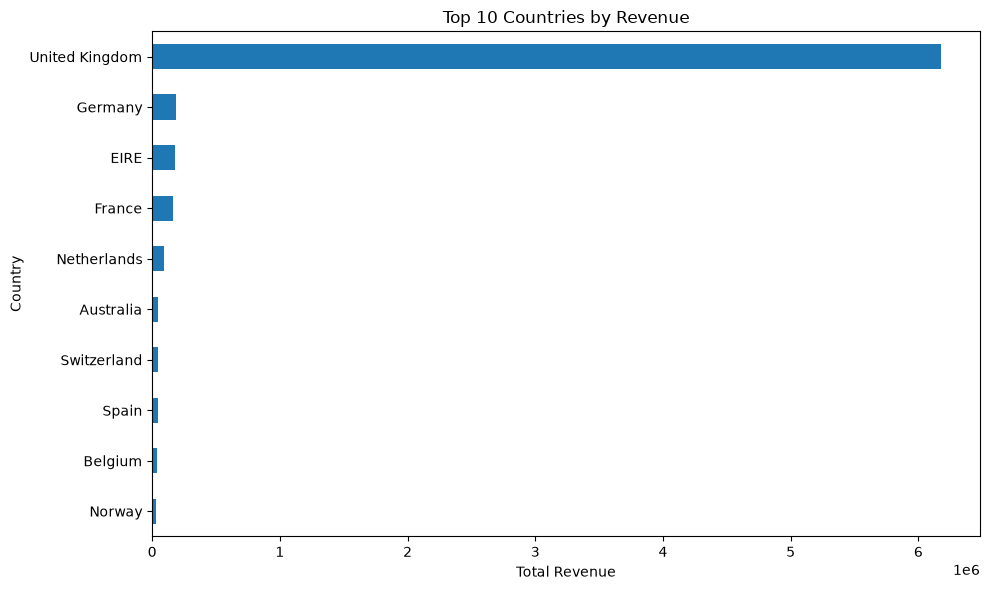

In [28]:
# Visualize top 10 countries by revenue

plt.figure(figsize=(10, 6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig("../visualizations/top_10_countries_revenue.png")
plt.show()

In [29]:
# Extract month from InvoiceDate

df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["TotalSales"]
    .sum()
)

print(monthly_sales)

Month
2010-12     562439.560
2011-01     431426.370
2011-02     373327.690
2011-03     494480.440
2011-04     383793.631
2011-05     540598.020
2011-06     488177.800
2011-07     493249.241
2011-08     503126.820
2011-09     730388.912
2011-10     793992.970
2011-11    1062470.390
2011-12     324437.040
Freq: M, Name: TotalSales, dtype: float64


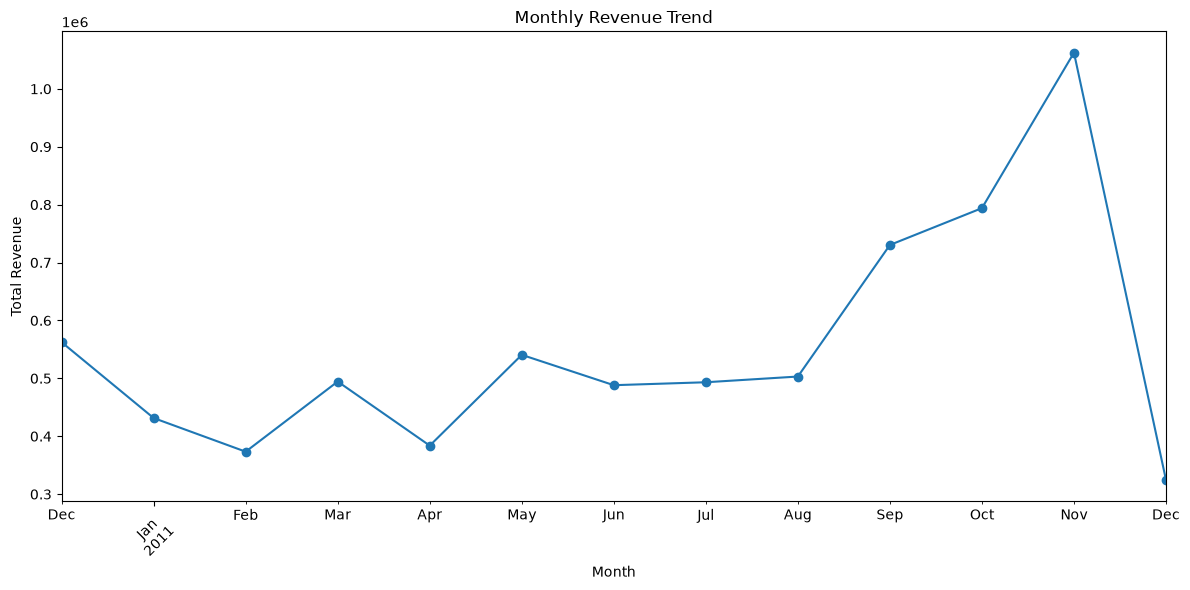

In [30]:
# Monthly revenue trend

plt.figure(figsize=(12, 6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visualizations/monthly_revenue_trend.png")
plt.show()

In [31]:
# Top 10 products by revenue

product_sales = (
    df.groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(product_sales)

Description
REGENCY CAKESTAND 3 TIER              93034.80
PARTY BUNTING                         64157.76
WHITE HANGING HEART T-LIGHT HOLDER    60604.10
JUMBO BAG RED RETROSPOT               46417.86
PAPER CHAIN KIT 50'S CHRISTMAS        36210.04
ASSORTED COLOUR BIRD ORNAMENT         35690.25
SPOTTY BUNTING                        33314.05
CHILLI LIGHTS                         32126.28
JAM MAKING SET WITH JARS              30359.99
SET OF 3 CAKE TINS PANTRY DESIGN      28078.15
Name: TotalSales, dtype: float64


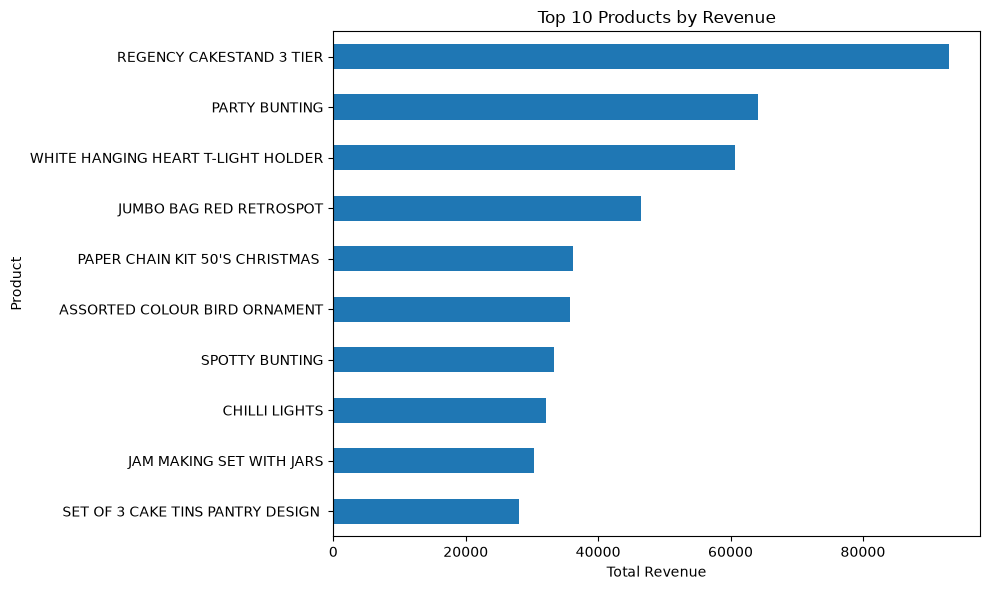

In [32]:
# Visualize top 10 products by revenue

plt.figure(figsize=(10, 6))

product_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig("../visualizations/top_10_products_revenue.png")
plt.show()

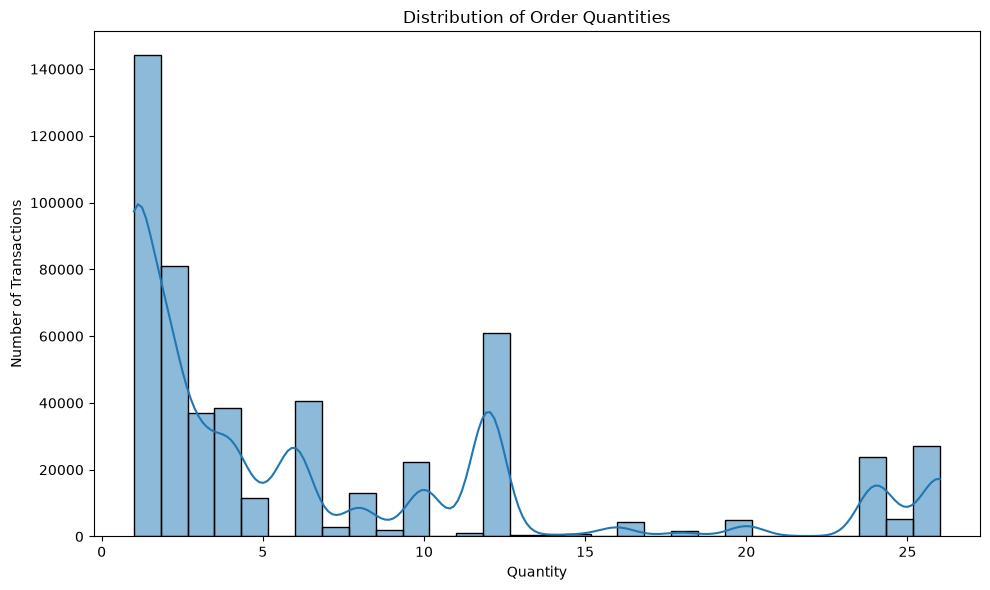

In [33]:
# Distribution of order quantities

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Quantity"],
    bins=30,
    kde=True
)

plt.title("Distribution of Order Quantities")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")
plt.tight_layout()

plt.savefig("../visualizations/quantity_distribution.png")
plt.show()

In [34]:
# Top 10 products by quantity sold

product_quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(product_quantity)

Description
JUMBO BAG RED RETROSPOT               21660
ASSORTED COLOUR BIRD ORNAMENT         20967
WHITE HANGING HEART T-LIGHT HOLDER    20954
PACK OF 72 RETROSPOT CAKE CASES       19828
LUNCH BAG RED RETROSPOT               14019
VICTORIAN GLASS HANGING T-LIGHT       13204
WORLD WAR 2 GLIDERS ASSTD DESIGNS     12386
PARTY BUNTING                         12239
RABBIT NIGHT LIGHT                    11957
POPCORN HOLDER                        11494
Name: Quantity, dtype: int64


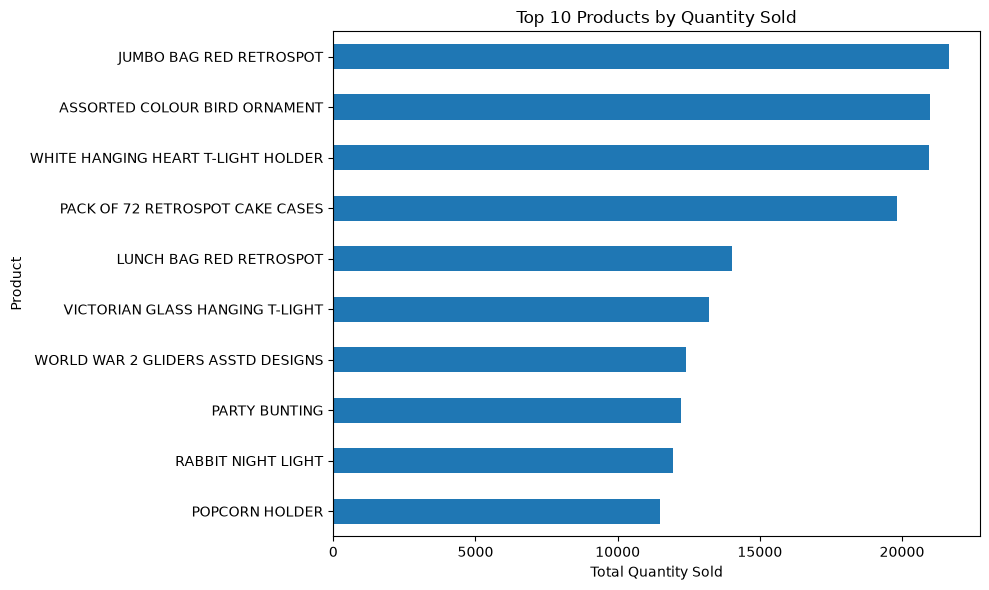

In [35]:
plt.figure(figsize=(10, 6))

product_quantity.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()

plt.savefig("../visualizations/top_10_products_quantity.png")
plt.show()

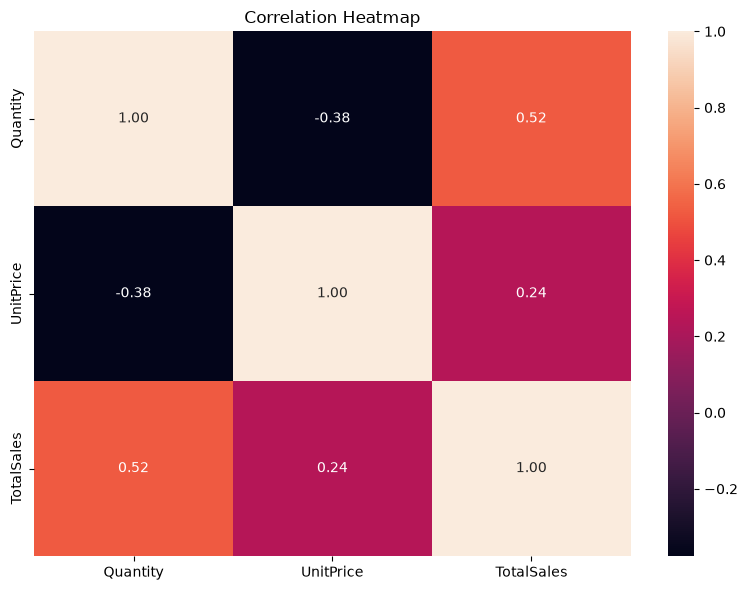

In [36]:
# Correlation analysis

numeric_columns = [
    "Quantity",
    "UnitPrice",
    "TotalSales"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("../visualizations/correlation_heatmap.png")
plt.show()

## 7. Key Findings

The analysis of the Online Retail dataset produced the following findings:

- The United Kingdom generated the highest revenue among all countries.
- November recorded the highest monthly revenue in the analyzed period.
- A small number of products contributed significantly to overall revenue.
- Order quantities are concentrated around relatively small values, with some high-volume transactions.
- Outlier analysis identified extreme values in both Quantity and UnitPrice.
- IQR-based capping was applied to reduce the influence of extreme numerical values while retaining the transactions.
- Cancelled transactions were removed because they contained negative quantities and could distort completed-sales analysis.

In [38]:
# Final verification

print("Final dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Final dataset shape: (524878, 10)
Duplicate rows: 33

Missing values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
TotalSales          0
Month               0
dtype: int64

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
TotalSales            float64
Month               period[M]
dtype: object


In [39]:
# Remove duplicates created after outlier treatment

duplicates_before = df.duplicated().sum()

print("Duplicates before final removal:", duplicates_before)

df = df.drop_duplicates().copy()

print("Duplicates after final removal:", df.duplicated().sum())
print("Final dataset shape:", df.shape)

Duplicates before final removal: 33
Duplicates after final removal: 0
Final dataset shape: (524845, 10)


In [40]:
# Recalculate TotalSales after final duplicate removal

df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

print("Final dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

Final dataset shape: (524845, 10)
Duplicate rows: 0


In [41]:
# Final data quality check

print("Final dataset shape:", df.shape)
print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nMaximum Quantity:", df["Quantity"].max())
print("Maximum UnitPrice:", df["UnitPrice"].max())

Final dataset shape: (524845, 10)

Duplicate rows: 0

Missing values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132183
Country             0
TotalSales          0
Month               0
dtype: int64

Maximum Quantity: 26
Maximum UnitPrice: 8.45


In [42]:
# Save the final cleaned dataset

output_path = "../output/cleaned_online_retail.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset exported successfully!")
print("Saved to:", output_path)

Cleaned dataset exported successfully!
Saved to: ../output/cleaned_online_retail.csv


In [43]:
# Create a summary of the cleaned dataset

summary = pd.DataFrame({
    "Metric": [
        "Final Rows",
        "Final Columns",
        "Duplicate Rows",
        "Missing Descriptions",
        "Missing Customer IDs",
        "Unique Products",
        "Unique Countries",
        "Total Revenue"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.duplicated().sum(),
        df["Description"].isnull().sum(),
        df["CustomerID"].isnull().sum(),
        df["StockCode"].nunique(),
        df["Country"].nunique(),
        round(df["TotalSales"].sum(), 2)
    ]
})

summary

,Metric,Value
0,Final Rows,524845.00
1,Final Columns,10.00
2,Duplicate Rows,0.00
3,Missing Descriptions,0.00
4,Missing Customer IDs,132183.00
5,Unique Products,3922.00
6,Unique Countries,38.00
7,Total Revenue,7181282.41


## 10. Conclusion

This project demonstrated the complete data cleaning, preprocessing, analysis, and visualization workflow using the Online Retail dataset.

The raw dataset was examined for missing values, duplicate records, cancelled transactions, invalid prices, and extreme numerical values. Missing product descriptions were handled, duplicate records were removed, cancelled transactions were excluded from completed-sales analysis, and outliers in Quantity and UnitPrice were treated using the IQR method.

A new TotalSales feature was created to support revenue analysis. Exploratory data analysis was then performed using Pandas, Matplotlib, and Seaborn.

The visualizations helped identify important patterns in country-wise revenue, monthly revenue, product performance, and order quantities.

Overall, the project demonstrates how data cleaning and visualization can transform raw transactional data into meaningful and understandable business insights.